## Прогнозирование годовых медицинских расходов пациента на основе табличных данных

## Участники:

- Алёна Лозинская
- Валентина Кулакова
- Дмитрий Волобуев
- Артур Григорян
- Ильсия Коткова
- Матвей Радаев

## Характеристика датасета

Общее количество записей: 5000  
Всего признаков: 20  
Тип данных: Синтетические  
Отсутствующие значения: Нет  

Описание признаков:
1. Демографические признаки:

| Столбец | Описание |
|----------|----------------------|
| **age** | Возраст пациента (18–90 лет) |
| **gender** | Пол пациента (мужской/женский) | 
| **bmi** | Индекс массы тела | 
  

2. Образ жизни и поведение в отношении здоровья

| Столбец | Описание |
|----------|----------------------|
| **smoker** | Статус курения (Да / Нет) |
| **physical_activity_level** | Уровень физической активности (низкий / средний / высокий) | 
| **daily_steps** | Среднее количество шагов в день | 
| **sleep_hours** | Средняя продолжительность сна (в часах) |
| **stress_level** | Уровень стресса по шкале от 1 до 10 | 

3. Медицинские состояния

| Столбец | Описание |
|----------|----------------------|
| **diabetes** | Наличие диабета (0 = Нет, 1 = Да) |
| **hypertension** | Индикатор высокого кровяного давления | 
| **heart_disease** | История сердечных заболеваний | 
| **asthma** | Индикатор состояния астмы |

4. Использование медицинских услуг

| Столбец | Описание |
|----------|----------------------|
| **doctor_visits_per_year** | Количество визитов к врачу в год |
| **hospital_admissions** | Количество госпитализаций | 
| **medication_count** | Количество принимаемых лекарств | 

5. Страхование и местоположение

| Столбец | Описание |
|----------|----------------------|
| **insurance_type** | Вид страхования (Отсутствует / Государственное / Частное) |
| **insurance_coverage_pct** | Процент страхового покрытия | 
| **city_type** | Жилой район (городской / полугородской / сельский) | 

6. Историческая стоимость

| Столбец | Описание |
|----------|----------------------|
| **previous_year_cost** | Медицинские расходы за предыдущий год |

7. Целевая переменная

| Столбец | Описание |
|----------|----------------------|
| **annual_medical_cost** | Общие годовые расходы на медицинское обслуживание (долл. США) |

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

import optuna
import shap

Установим random state для воспроизводимости результатов.

In [112]:
RANDOM_STATE = 42

# Exploratory Data Analysis (EDA) 

In [113]:
df = pd.read_csv('C:/Users/sulta/Downloads/archive/medical_cost_prediction_dataset.csv')

df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


In [114]:
# выделяем целевую переменную 
target = df['annual_medical_cost']

### Корректировка целевой переменной

Зачем делаем корректировку целевой переменной?

- Изначально annual_medical_cost - это чистые расходы пациента с учётом того, что страховая покрыла insurance_coverage_pct % стоимости. 

- Но для моделирования реального сценария страховщика мы должны получать оценку **полной** стоимости медицинских расходов пациента, чтобы подобрать для него страховку. Поэтому мы восстанавливаем полную стоимость по формуле.

- По этой же причине insurance_type и insurance_coverage_pct исключаются из предикторов, т.к. в реальном сценарии мы предполагаем, что у пациента пока нет никакой страховки.

In [115]:
df["insurance_coverage_pct"] = df["insurance_coverage_pct"].astype(float)

In [116]:
df["annual_medical_cost"] = round(df["annual_medical_cost"] / (1 - df["insurance_coverage_pct"]/100))

In [117]:
df.drop(columns=["insurance_type", "insurance_coverage_pct"], axis=1, inplace=True)

In [118]:
# определяем типы признаков
df.dtypes

age                          int64
gender                      object
bmi                        float64
smoker                      object
diabetes                     int64
hypertension                 int64
heart_disease                int64
asthma                       int64
physical_activity_level     object
daily_steps                  int64
sleep_hours                float64
stress_level                 int64
doctor_visits_per_year       int64
hospital_admissions          int64
medication_count             int64
city_type                   object
previous_year_cost           int64
annual_medical_cost        float64
dtype: object

Приведем признаки smoker и ggender к единому виду с остальными бинарными признаками (No = 0, Yes = 1, male = 1, female - 0).

In [119]:
df['smoker'] = df['smoker'].replace({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})

C:\Users\sulta\AppData\Local\Temp\ipykernel_18488\2906321866.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'] = df['smoker'].replace({'Yes': 1, 'No': 0})
C:\Users\sulta\AppData\Local\Temp\ipykernel_18488\2906321866.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})


In [120]:
# проверяем сколько нулевых значений

print("Количество нулевых значений в признаках:")
display(df.eq(0).sum())

Количество нулевых значений в признаках:


age                           0
gender                     2519
bmi                           0
smoker                     3779
diabetes                   3962
hypertension               3560
heart_disease              4289
asthma                     4518
physical_activity_level       0
daily_steps                   0
sleep_hours                   0
stress_level                  0
doctor_visits_per_year       81
hospital_admissions        1819
medication_count            609
city_type                     0
previous_year_cost            0
annual_medical_cost           0
dtype: int64

Нулевые значения присутствуют только в тех признаках, в которых они могут быть по смыслу.

In [121]:
# проверка на дубликаты
df.duplicated().sum()

np.int64(0)

Данные не содержат повторов. Дополнительная очистка от дубликатов не требуется.

In [122]:
# основные описательные статистики
df.describe()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,previous_year_cost,annual_medical_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,53.299000,0.496200,25.970820,0.244200,0.207600,0.288000,0.14220,0.096400,7993.216800,6.488140,5.475400,4.030600,1.001000,3.509000,10248.515400,19123.380600
std,20.646851,0.500036,5.046651,0.429655,0.405629,0.452876,0.34929,0.295169,4052.127069,1.443361,2.892312,2.010689,0.978566,2.292721,5626.095015,6995.684871
min,18.000000,0.000000,6.400000,0.000000,0.000000,0.000000,0.00000,0.000000,1004.000000,4.000000,1.000000,0.000000,0.000000,0.000000,500.000000,3594.000000
25%,36.000000,0.000000,22.600000,0.000000,0.000000,0.000000,0.00000,0.000000,4545.000000,5.200000,3.000000,3.000000,0.000000,1.000000,5342.750000,13934.000000
50%,53.000000,0.000000,25.900000,0.000000,0.000000,0.000000,0.00000,0.000000,7989.000000,6.500000,5.000000,4.000000,1.000000,3.000000,10281.000000,18538.000000
75%,71.000000,1.000000,29.400000,0.000000,0.000000,1.000000,0.00000,0.000000,11532.250000,7.700000,8.000000,5.000000,2.000000,6.000000,15034.500000,23387.250000
max,89.000000,1.000000,43.600000,1.000000,1.000000,1.000000,1.00000,1.000000,14999.000000,9.000000,10.000000,14.000000,6.000000,7.000000,19996.000000,51016.000000


 - Подозрительный минимум у признака bmi (индекс массы тела) - 6.4. Это аномально низко, т.к. обычный диапазон 16-40. Это может быть ошибкой ввода или экстремальным случаем;
 - Правостороннее распределение по целевой переменной. Есть небольшая группа людей с высокими расходами;
 - Большой разброс значений (age: 18-89, annual_medical_cost: 404 - 44792). Для моделей, чувствительных к масштабу (SVM, KNN, Neural Networks, Linear Regression), потребуется нормализация (MinMaxScaler) или стандартизация (StandardScaler).

In [123]:
# разделяем признаки по категориям

numeric = ['age', 'bmi', 'daily_steps', 'sleep_hours',
            'doctor_visits_per_year', 'hospital_admissions', 'medication_count',
           'previous_year_cost', 'stress_level']

categorical = ['physical_activity_level', 'city_type', 'gender', 'smoker', 'diabetes', 'hypertension', 'heart_disease', 'asthma']

binary = ['gender', 'smoker', 'diabetes', 'hypertension', 'heart_disease', 'asthma']

## 1. Визуализации числовых и категориальных переменных

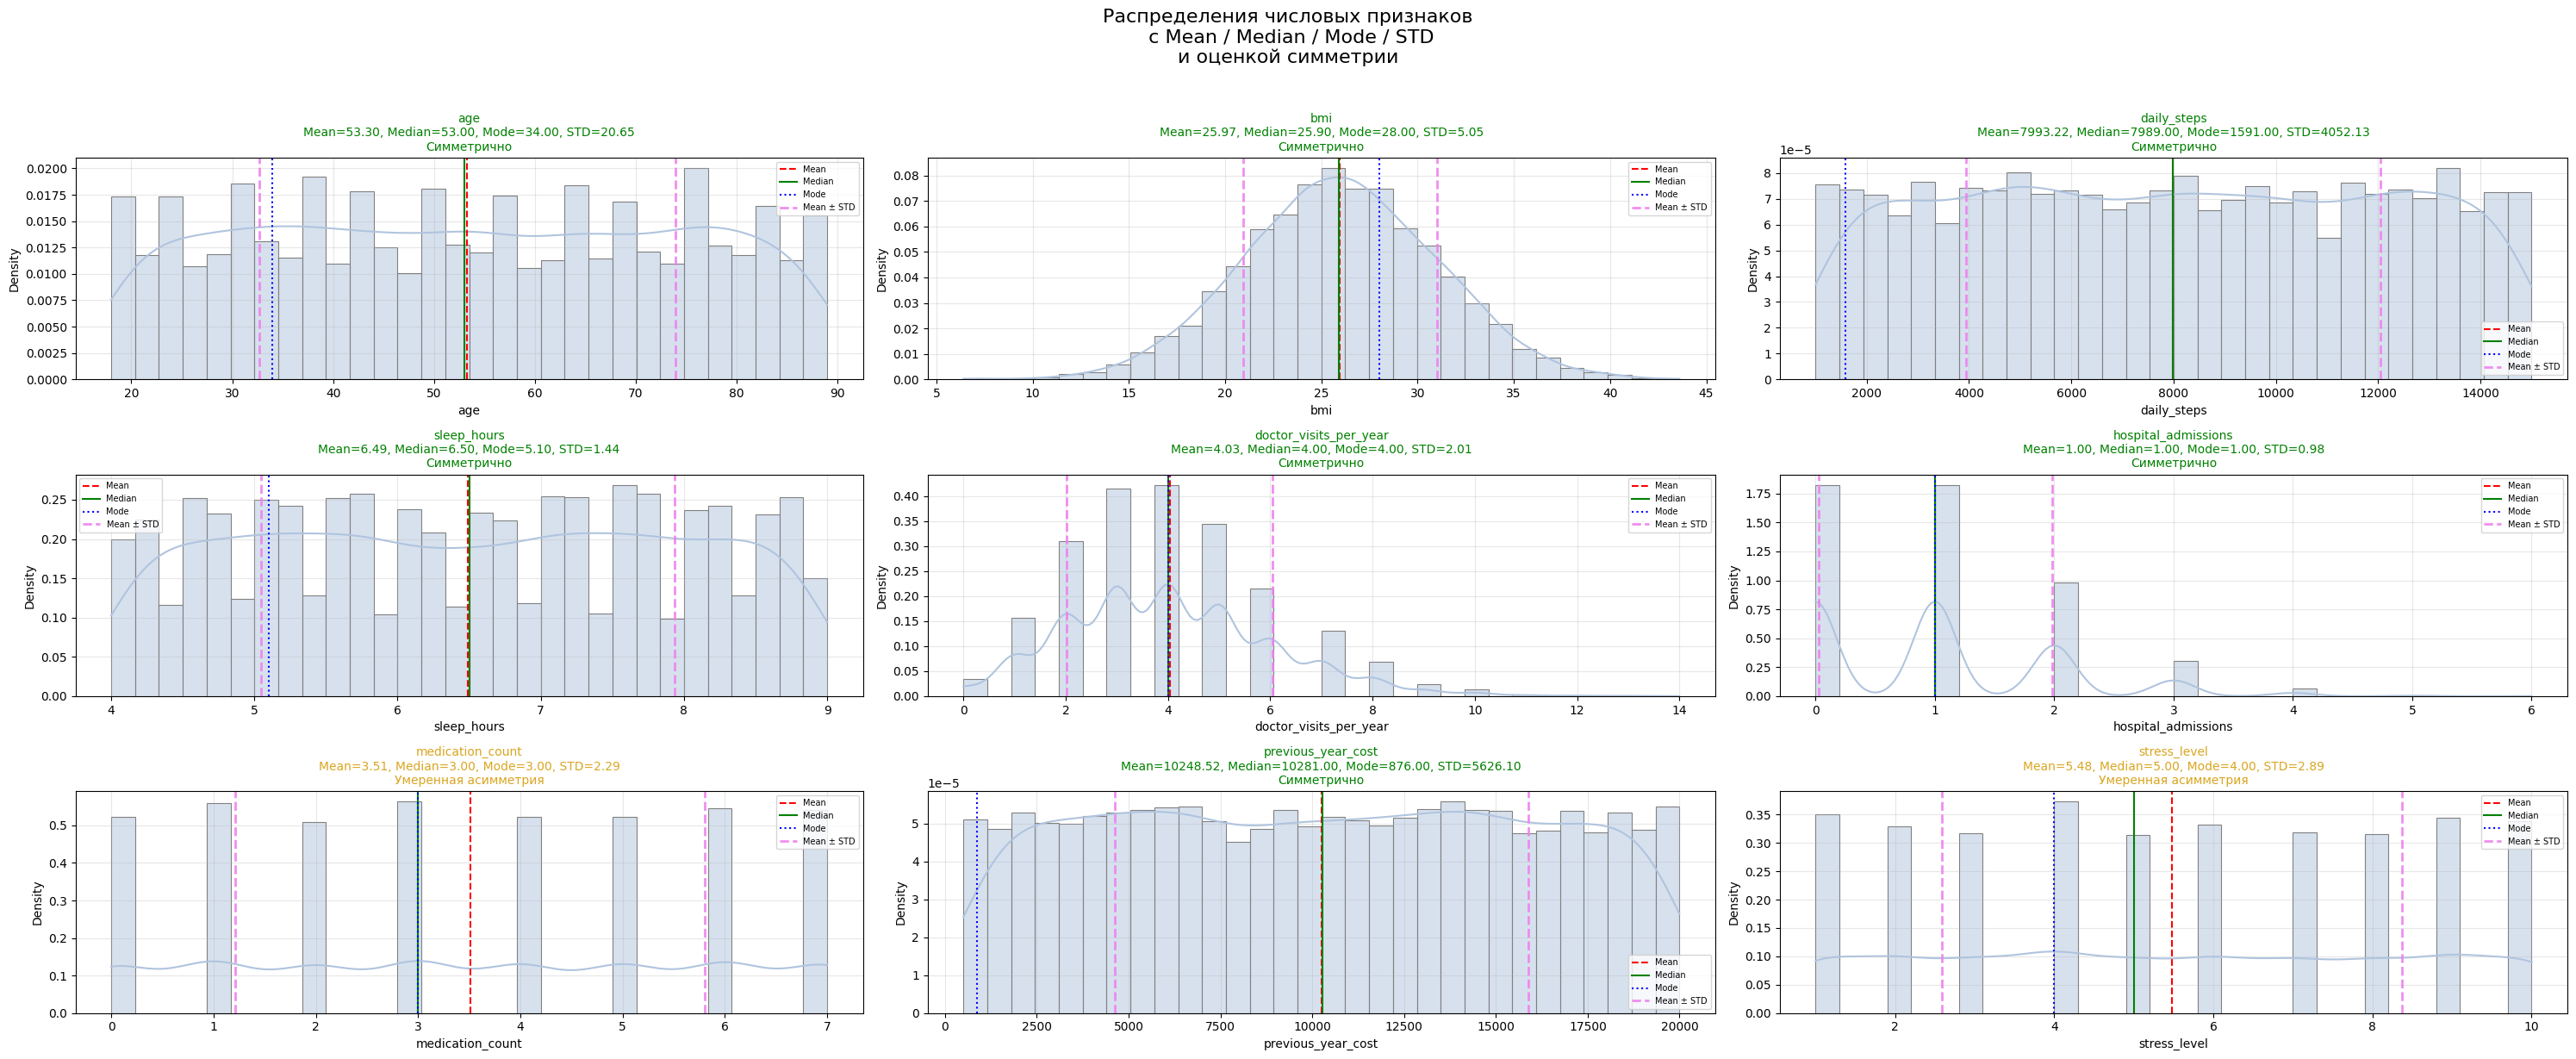

In [124]:
# распределения числовых признаков
n_cols = 3
n_rows = (len(numeric) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric):

    data = df[col].dropna()
   
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode()[0] if not data.mode().empty else np.nan
    std_val = data.std()

    diff = abs(mean_val - median_val)
    skew_ratio = diff / std_val if std_val != 0 else 0

    if skew_ratio < 0.1:
        color = 'green'
        label = 'Симметрично'
    elif skew_ratio < 0.3:
        color = 'goldenrod'
        label = 'Умеренная асимметрия'
    else:
        color = 'crimson'
        label = 'Сильная асимметрия'

    sns.histplot(
        data, bins=30, kde=True,
        color='lightsteelblue', edgecolor='gray', linewidth=0.8,
        ax=axes[i], stat='density'
    )

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')
    axes[i].axvline(mode_val, color='blue', linestyle=':', linewidth=1.5, label='Mode')
    axes[i].axvline(mean_val + std_val, color='violet', linestyle='--', linewidth=2, alpha=0.9, label='Mean ± STD')
    axes[i].axvline(mean_val - std_val, color='violet', linestyle='--', linewidth=2, alpha=0.9)

    axes[i].set_title(
        f"{col}\nMean={mean_val:.2f}, Median={median_val:.2f}, Mode={mode_val:.2f}, STD={std_val:.2f}\n{label}",
        fontsize=10, color=color
    )

    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=7)

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Распределения числовых признаков\n с Mean / Median / Mode / STD\nи оценкой симметрии", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Большая часть признаков распределены симметрично, тогда как medication_count и stress_level имеют умеренную асимметрию.

- У признака previous_year_cost очень высокий разброс (STD = 5626.10), есть люди с экстремально высокими расходами (выбросы).

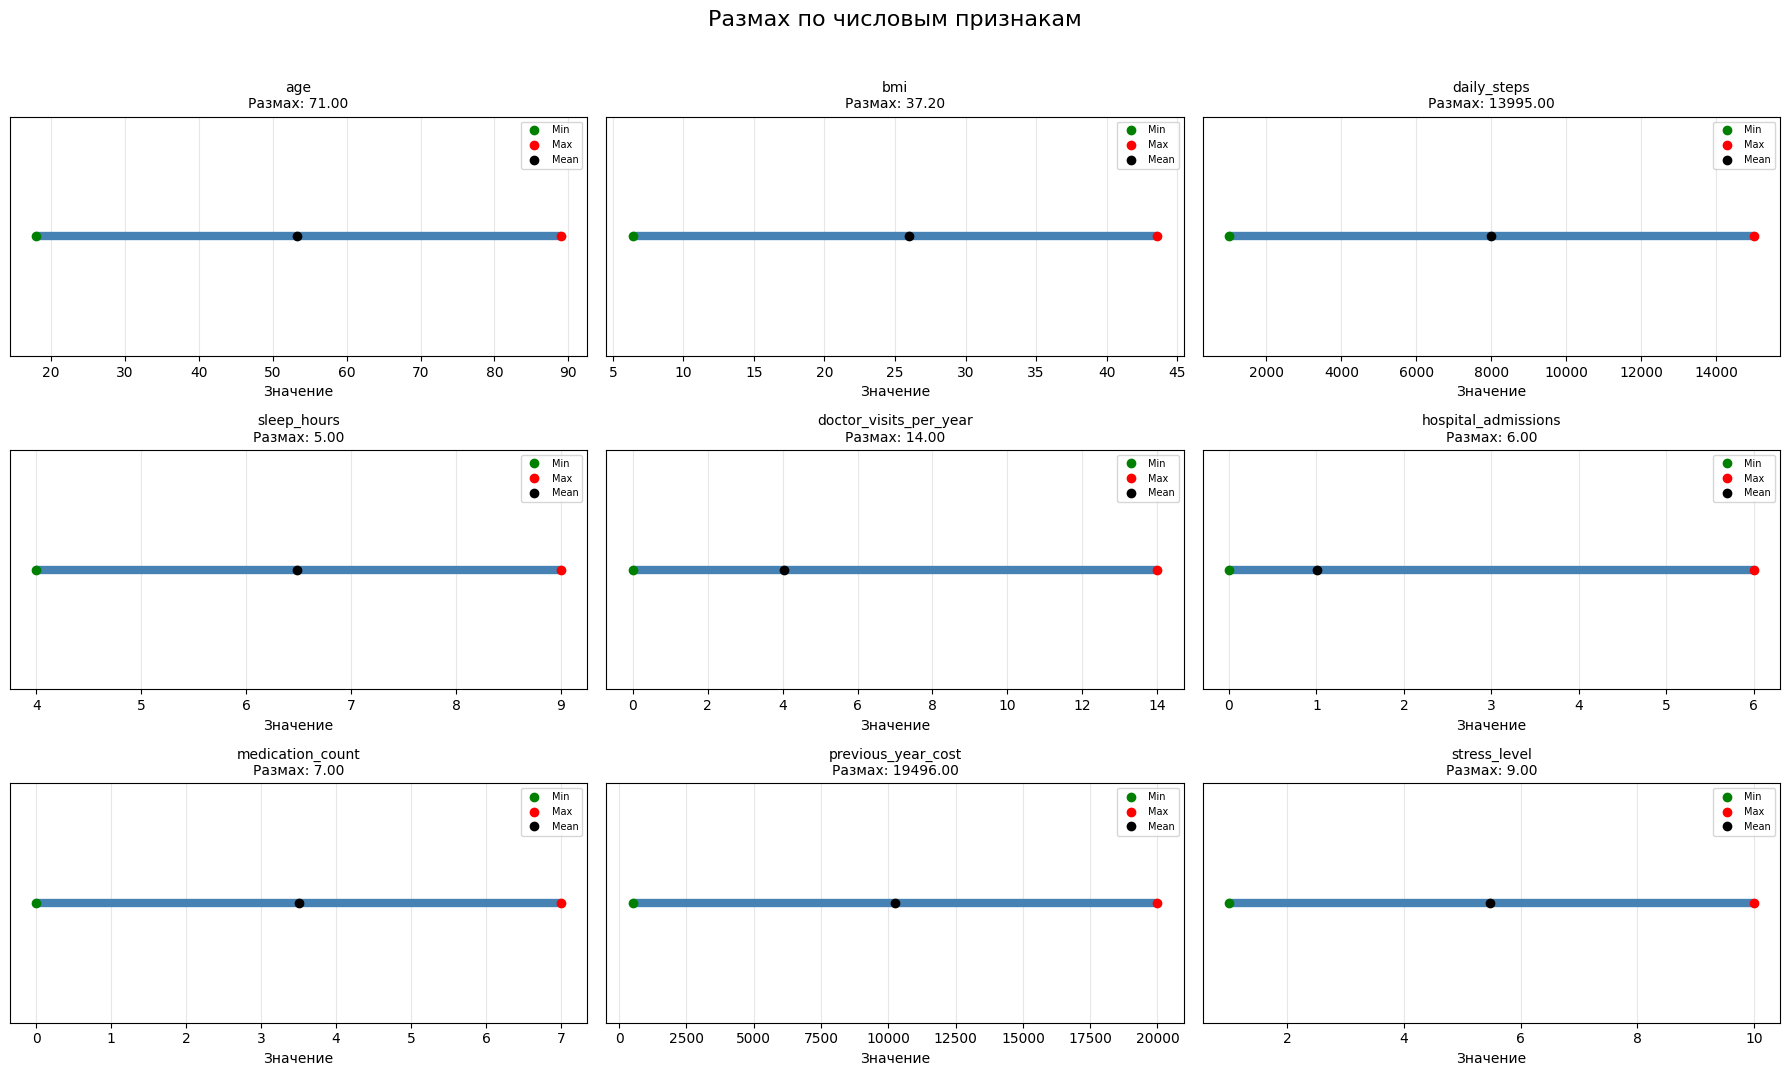

In [125]:
# размахи числовых признаков
n_cols = 3
n_rows = (len(numeric) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric):

    data = df[col].dropna()

    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    rng = max_val - min_val

    axes[i].hlines(1, min_val, max_val, color='steelblue', linewidth=6)
    axes[i].plot(min_val, 1, 'go', label='Min')
    axes[i].plot(max_val, 1, 'ro', label='Max')
    axes[i].plot(mean_val, 1, 'ko', label='Mean')

    axes[i].set_title(f'{col}\nРазмах: {rng:.2f}', fontsize=10)
    axes[i].set_yticks([])
    axes[i].set_xlabel('Значение')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].legend(fontsize=7, loc='upper right')

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Размах по числовым признакам", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Есть большая разница в масштабах: daily_steps и previous_year_cost имеют диапазоны в тысячах, а stress_level, sleep_hours, hospital_admissions имеют диапазоны в единицах, т.е. признаки находятся в совершенно разных числовых диапазонах.

- Призаки hospital_admissions и doctor_visits_per_year "скошены вправо" (среднее ближе к минимуму).

In [126]:
# Асимметрия распределений
df[numeric].skew()

age                       0.009598
bmi                      -0.007610
daily_steps               0.004649
sleep_hours              -0.001371
doctor_visits_per_year    0.550993
hospital_admissions       0.888548
medication_count          0.001158
previous_year_cost        0.003471
stress_level              0.016389
dtype: float64

У признака hospital_admissions наблюдается сильная правосторонняя асимметрия (0.89), а doctor_visits_per_year она умеренная (0.55).

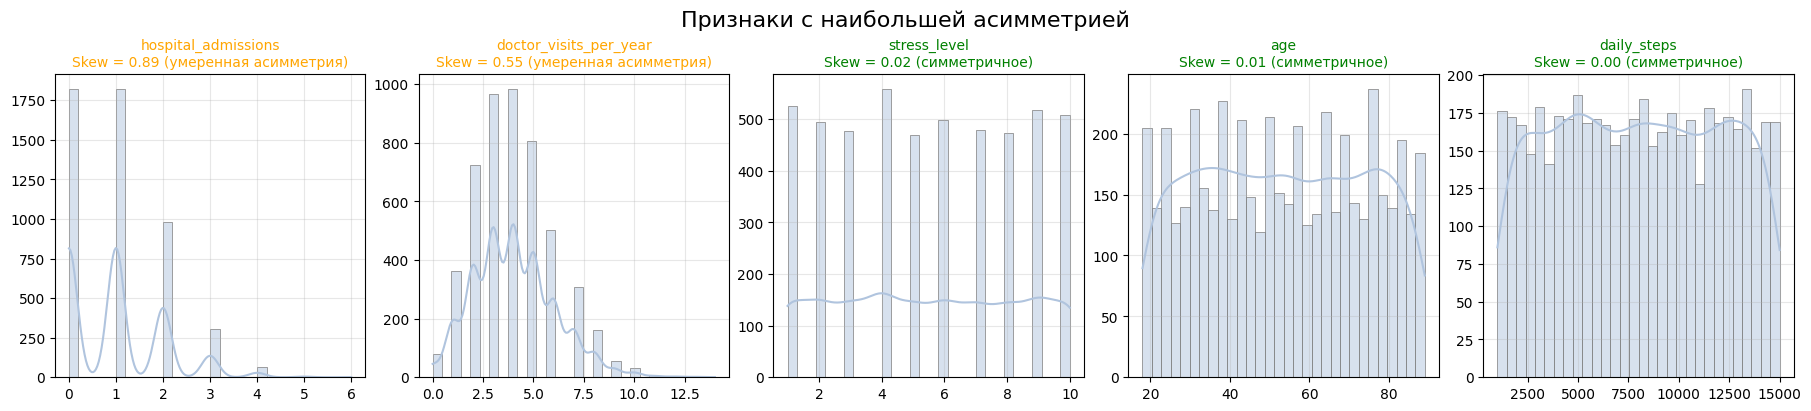

In [127]:
# признаки с наибольшей асимметрией
skew_vals = df[numeric].skew().sort_values(ascending=False)
problematic = skew_vals.head().index.tolist()

fig, axes = plt.subplots(1, len(problematic), figsize=(18, 4), constrained_layout=True)
axes = np.atleast_1d(axes) 

for ax, col in zip(axes, problematic):

    data = df[col].dropna()
    skew_val = data.skew()

    sns.histplot(data, bins=30, kde=True, ax=ax, color="lightsteelblue", edgecolor="gray")

    if abs(skew_val) < 0.3:
        color = "green"
        skew_type = "симметричное"
    elif abs(skew_val) < 1:
        color = "orange"
        skew_type = "умеренная асимметрия"
    else:
        color = "red"
        skew_type = "сильная асимметрия"

    ax.set_title(f"{col}\nSkew = {skew_val:.2f} ({skew_type})", fontsize=10, color=color)
    ax.grid(alpha=0.3)
    ax.set(xlabel="", ylabel="")

fig.suptitle("Признаки с наибольшей асимметрией", fontsize=16)
plt.show()

Большинство признаков имеют почти идеальную симметрию. Подтверждается умеренная асимметрия признаков hospital_admissions и doctor_visits_per_year.

Если в будущем нам нужно будет обоработать скошенные признаки, то для удобства мы разделяем их в разные переменные.

In [128]:
numeric_skewed = ['previous_year_cost', 'daily_steps']

numeric_standard = ['age', 'bmi', 'sleep_hours', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'stress_level']

In [129]:
# функция для обнаружения выбросов (IQR метод)
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': len(outliers),
        'outliers_percent': round(len(outliers) / len(df) * 100, 2),
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR
    }

outliers_info = {}

for col in numeric:
    info = find_outliers_iqr(df, col)
    outliers_info[col] = info
    if info['outliers_percent'] > 0:
        print(f"{col}:")
        print(f"  Границы: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
        print(f"  Выбросов: {info['outliers_count']} ({info['outliers_percent']}%)")
        print()

bmi:
  Границы: [12.40, 39.60]
  Выбросов: 39 (0.78%)

doctor_visits_per_year:
  Границы: [0.00, 8.00]
  Выбросов: 105 (2.1%)

hospital_admissions:
  Границы: [-3.00, 5.00]
  Выбросов: 2 (0.04%)



 - bmi: нижние выбросы (12.4) — скорее ошибка, верхние (39.6) — возможны.
 - doctor_visits_per_year: 8 визитов/год — это норма, верхние "выбросы" оставляем.
 - hospital_admissions: 2 случая — редкие, но валидные, не трогаем.

 Итого: только признак bmi требует обработки.

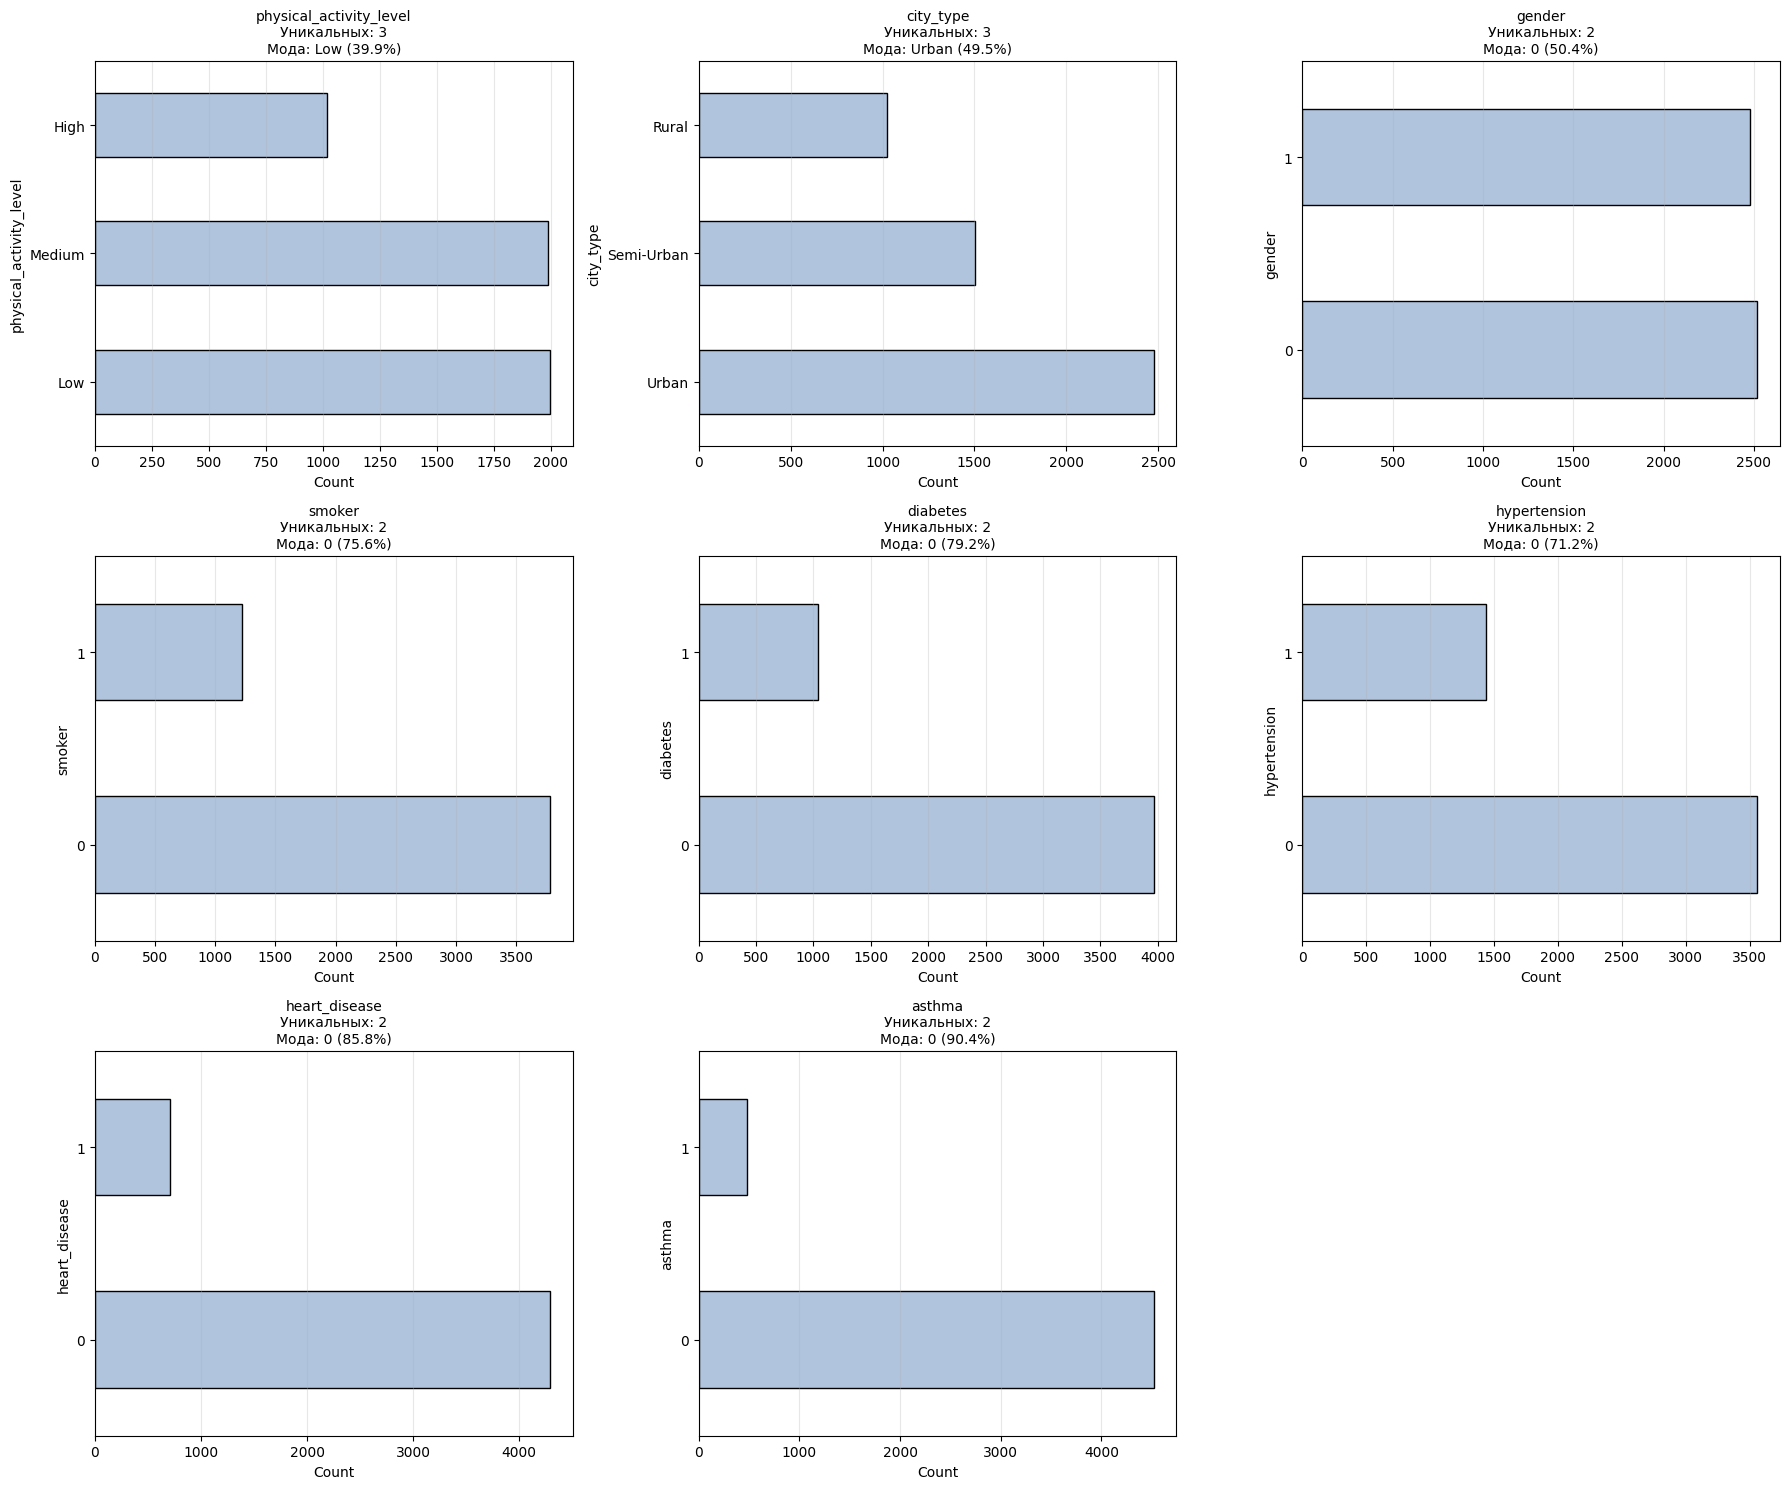

In [130]:
# распределения категориальных признаков
n_cols = 3  
n_rows = (len(categorical) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical):

    counts = df[col].value_counts()
    counts.plot(kind='barh', color='lightsteelblue', edgecolor='black', ax=axes[i])
    
    mode_val = df[col].mode()[0]
    mode_percent = (counts.iloc[0] / len(df)) * 100
    
    axes[i].set_title(f'{col}\nУникальных: {df[col].nunique()}\nМода: {mode_val} ({mode_percent:.1f}%)', fontsize=10)
    axes[i].set_xlabel('Count')
    axes[i].grid(axis='x', alpha=0.3)

for j in range(len(categorical), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

Во всех "медицинских" признаках (asthma, heart_disease, diabetes, smoker, hypertension) наблюдается сильный дисбаланс классов. Категория 1 ("No" - нет заболевания/вредной привычки) значительно преобладает. Это типично для медицинских данных, где здоровых людей больше, чем больных.

interval columns not set, guessing: ['age', 'gender', 'bmi', 'smoker', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'previous_year_cost', 'annual_medical_cost']


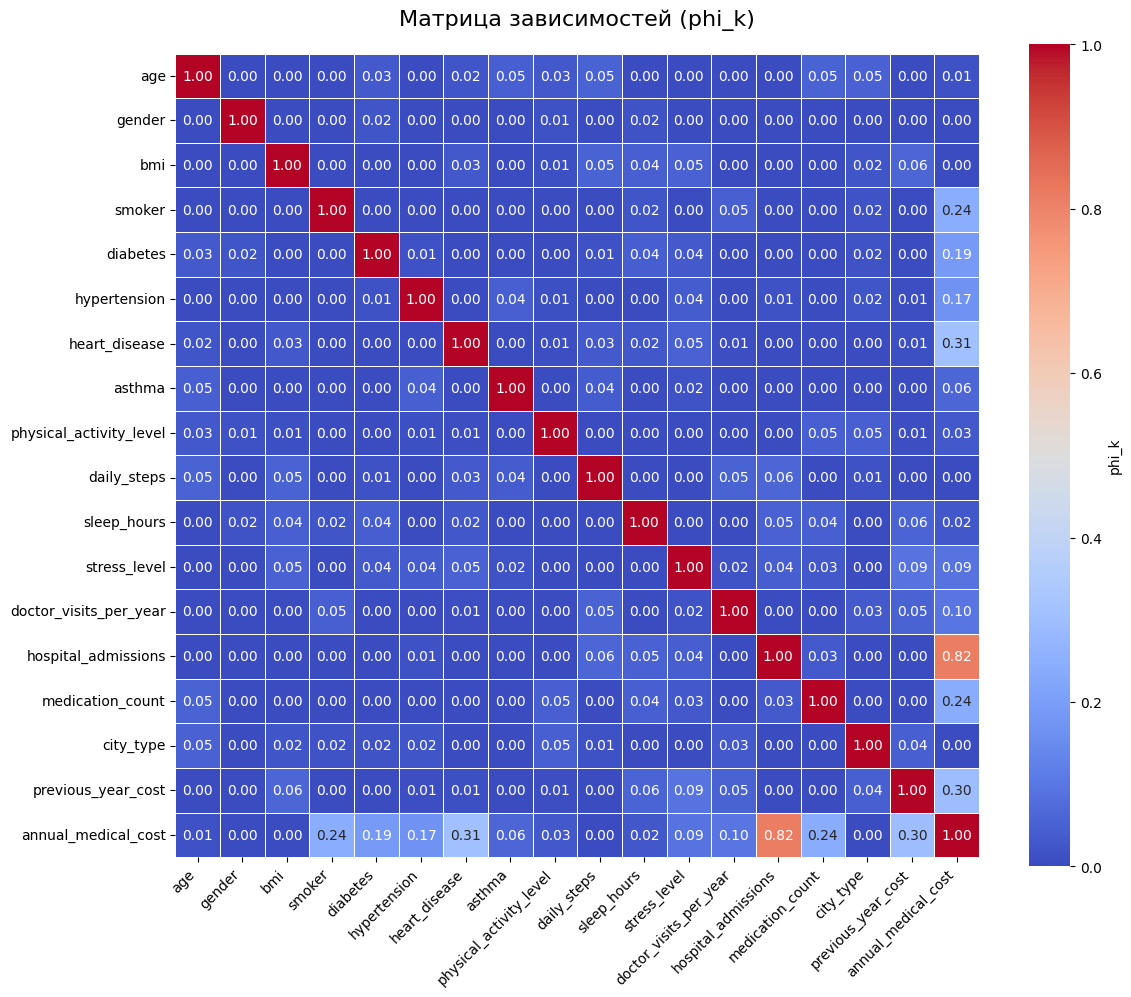

In [131]:
# матрица зависимостей всех признаков и таргета
phik_matrix = df.phik_matrix()

plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_matrix,
    annot=True,         
    fmt=".2f",         
    cmap="coolwarm",    
    vmin=0,
    vmax=1,          
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "phi_k"}
)

plt.title("Матрица зависимостей (phi_k)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- Сильных связей мало: большинство зависимостей находятся на низком уровне, что говорит о том, что признаки слабо коррелируют друг с другом.
- Наиболее связан с целевой переменной признак hospital_admissions (0.74).

- Признак heart_disease (0.32), previous_year_cost (0.28), smoker (0.25), diabetes (0.2), hypertension (0.17) и medication_count (0.25) имеют одни из самых заметных связей с annual_medical_cost.

## 2. Анализ целевой переменной

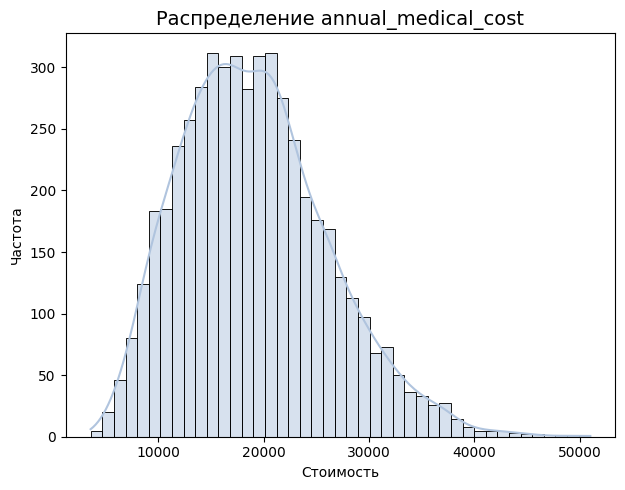

In [132]:
# посмотрим распределение целевой переменной
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='annual_medical_cost', kde=True, color='lightsteelblue', edgecolor='black')
plt.title("Распределение annual_medical_cost", fontsize=14)
plt.xlabel("Стоимость")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

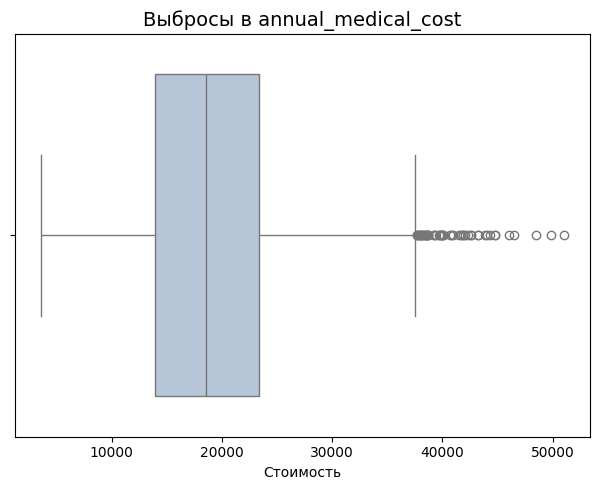

In [133]:
# визуализируем выбросы
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
sns.boxplot(x=df['annual_medical_cost'], color='lightsteelblue')
plt.title("Выбросы в annual_medical_cost", fontsize=14)
plt.xlabel("Стоимость")

plt.tight_layout()
plt.show()

- Мы видим явный "длинный хвост" вправо - большинство людей имеют относительно низкие медицинские расходы.
- Есть небольшое количество записей с очень высокими расходами, что говорит о наличии выбросов.

In [134]:
df['annual_medical_cost'].skew()

np.float64(0.5598543651903898)

Такое значение (0.56) подтверждает визуальную оценку: распределение имеет умеренную правостороннюю асимметрию.

interval columns not set, guessing: ['age', 'gender', 'bmi', 'smoker', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'previous_year_cost', 'annual_medical_cost']


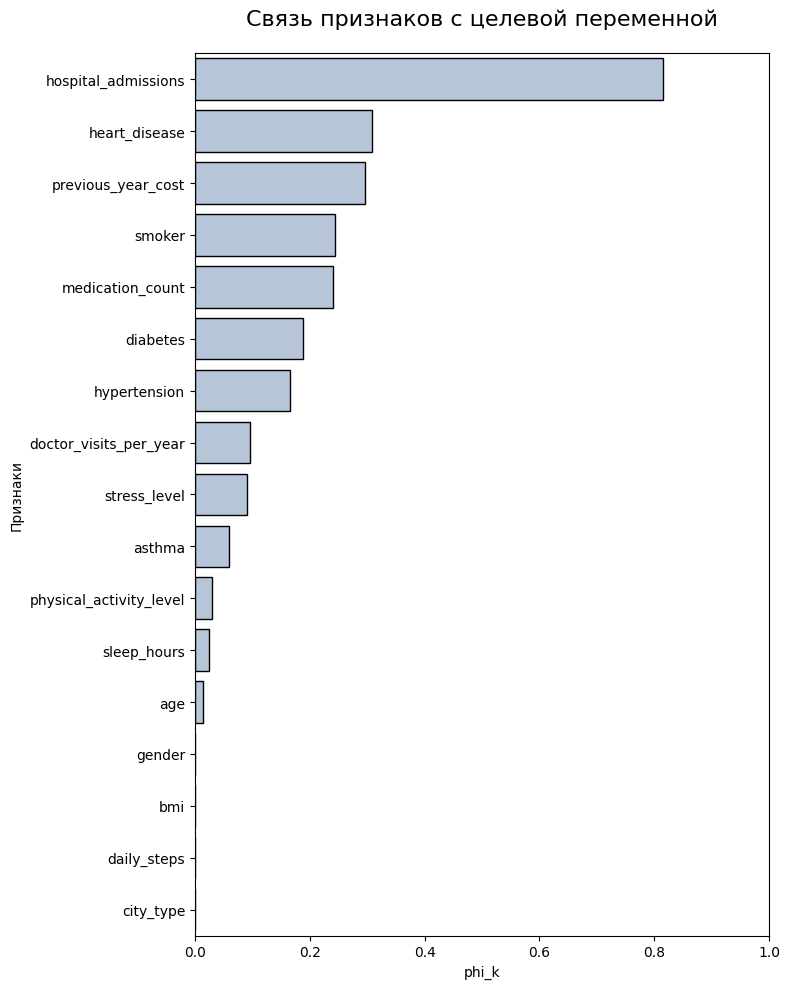

In [135]:
# рассмотрим отдельно связь признаков с целевой переменной
phik_matrix = df.phik_matrix()
target_corr = phik_matrix['annual_medical_cost'].sort_values(ascending=False)

target_corr = target_corr.drop(labels='annual_medical_cost')

plt.figure(figsize=(8, 10))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    orient='h',
    color='lightsteelblue', 
    edgecolor='black'
)

plt.title("Связь признаков с целевой переменной", fontsize=16, pad=20)
plt.xlabel("phi_k")
plt.ylabel("Признаки")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

- Наиболее информативный признак: hospital_admissions - он показывают самую высокую связь с целевой переменной.

- Умеренная зависимость: heart_disease, previous_year_cost, smoker, medication_count, diabetes, hypertension.

- Остальные признаки имеют слабую зависимость, а gender, bmi, daily_steps и city_type не обнаруживают никакой связи.

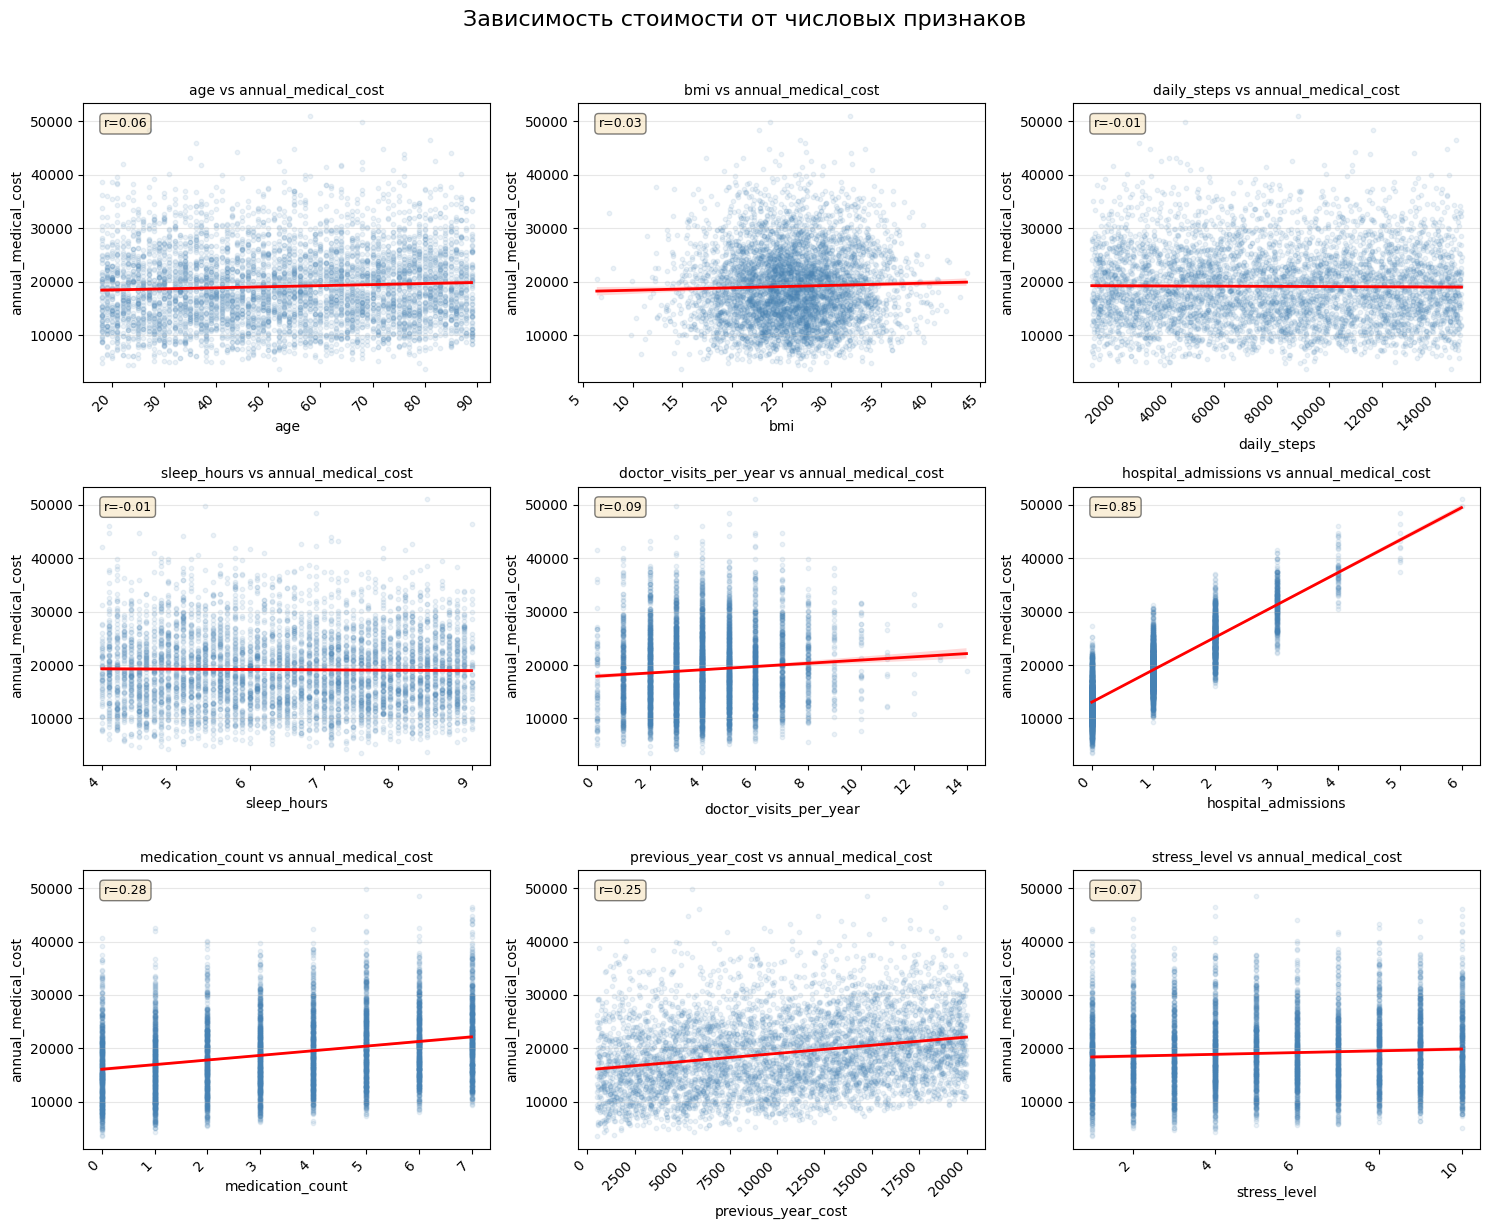

In [136]:
# связь между числовыми признаками и целевой переменной
target_col = "annual_medical_cost" 

n_cols = 3
n_rows = -(-len(numeric) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numeric):
    ax = axes[i]
    
    sns.regplot(
        data=df,
        x=feature,
        y=target_col,
        scatter_kws={'alpha': 0.1, 's': 10, 'color': 'steelblue'},  # было 0.3
        line_kws={'color': 'red', 'linewidth': 2},
        ax=ax
    )
    
    corr = df[[feature, target_col]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r={corr:.2f}', transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_title(f"{feature} vs {target_col}", fontsize=10)
    ax.set_xlabel(feature)
    ax.set_ylabel(target_col)
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

for j in range(len(numeric), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Зависимость стоимости от числовых признаков", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

- Мы видим основной признак hospital_admissions (r=0.85) - чем больше госпитализаций, тем выше расходы.
- Умеренная корреляция с признаками medication_count (чем больше лекарств принимает пациент, тем выше расходы), previous_year_cost  (расходы в прошлом году предсказывают расходы в этом) и doctor_visits_per_year (больше визитов - чуть выше расходы).
-  Возраст и вес почти не влияют на стоимость напрямую (в линейном смысле).

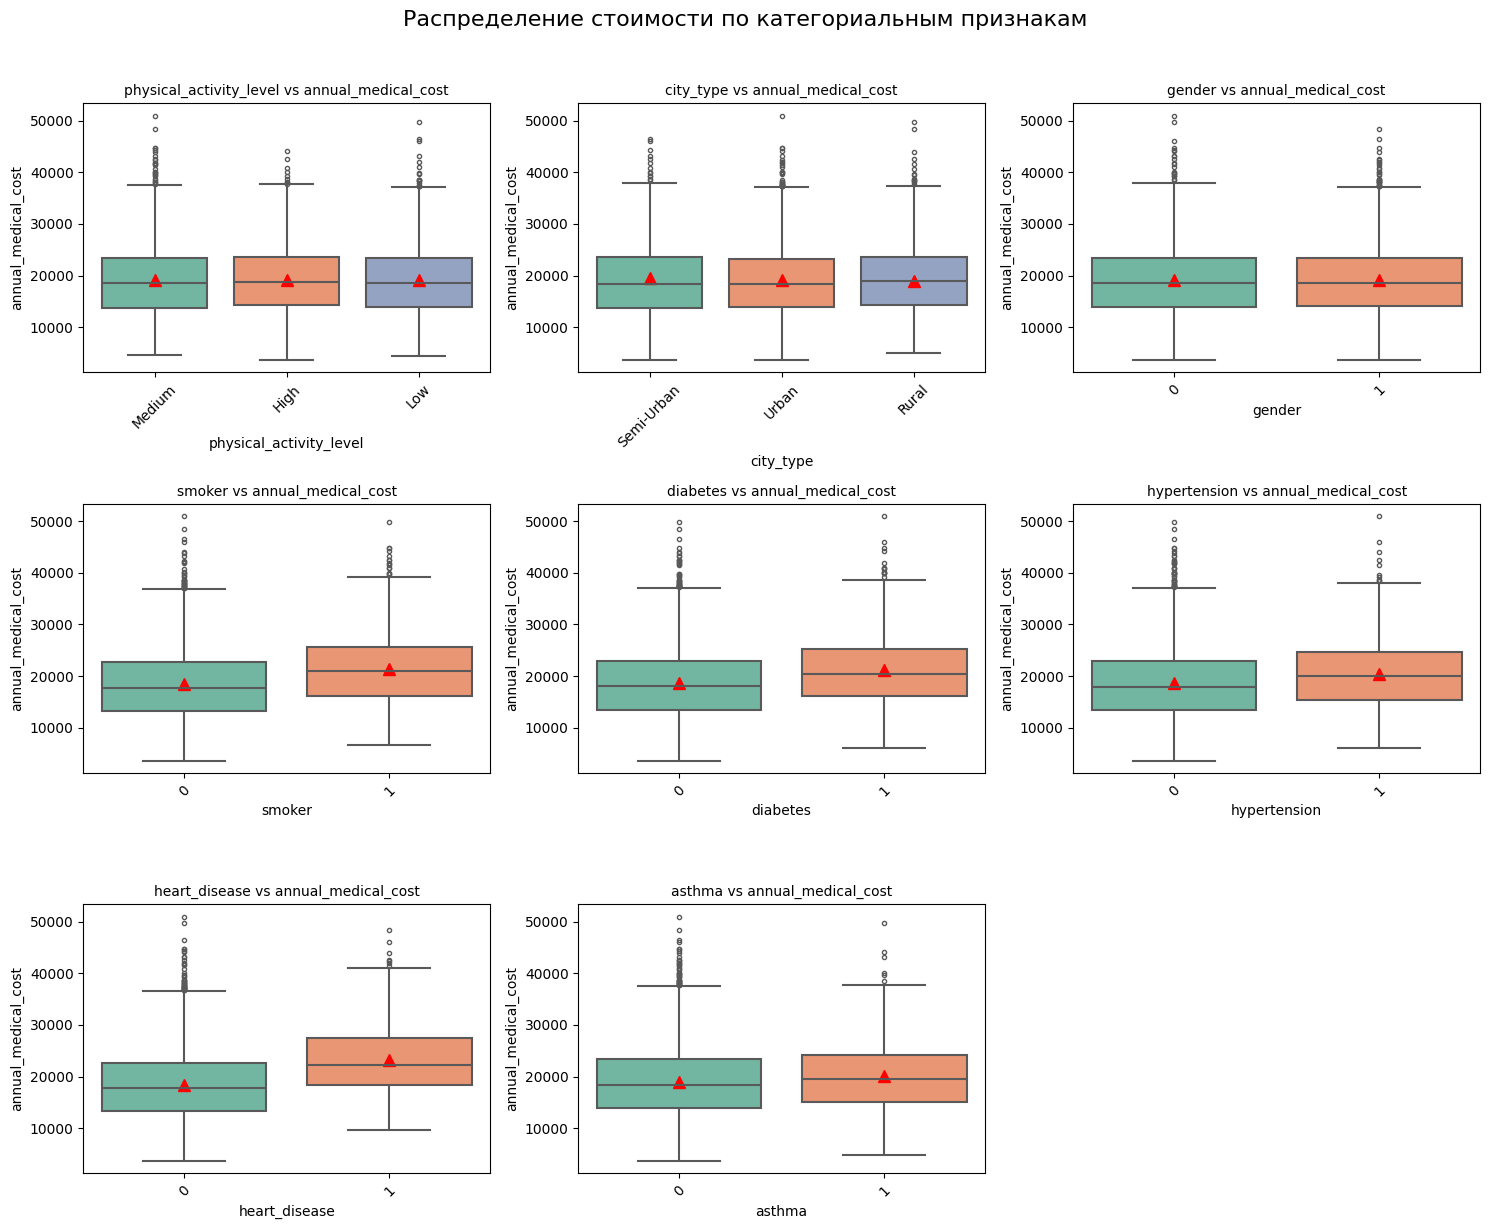

In [137]:
# зависимость категориальных признаков и числовой целевой переменной
target_col = "annual_medical_cost"

n_cols = 3
n_rows = -(-len(categorical) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical):
    
    sns.boxplot(
        data=df,
        x=col,
        y=target_col,
        ax=axes[i],
        hue=col,          
        palette="Set2",     
        legend=False,       
        fliersize=3,
        linewidth=1.5
    )
    
    means = df.groupby(col)[target_col].mean()
    for j, category in enumerate(means.index):
        axes[i].plot(
            j,
            means[category],
            'r^',
            markersize=8,
            label='Среднее' if j == 0 else ""
        )
    
    axes[i].set_title(f"{col} vs {target_col}", fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical), len(axes)):
    fig.delaxes(axes[j]) 

fig.suptitle("Распределение стоимости по категориальным признакам", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Практически все бинарные признаки здоровья (heart_disease, smoker, hypertension) показывают сдвиг медианы вверх для категории "Yes". Это подтверждает, что наличие заболеваний — ключевой фактор стоимости.
- Слабое влияние демографии и образа жизни.

Выводы по результатам EDA:

1. Пропуски отсутствуют, но есть критическая аномалия в BMI (минимум 6.4). Требуется обрезка (clip) до физиологического минимума (~15).
2. Разброс значений признаков огромен (от 1 до 20 000). Требуется масштабирование (StandardScaler).
3. Главный признак, который влияет на стоимость - hospital_admissions (каждая дополнительная госпитализация линейно и предсказуемо увеличивает расходы).
4. Наличие heart_disease, hypertension и статус smoker статистически значимо сдвигают распределение расходов вверх.
5. Признаки previous_year_cost и medication_count имеют умеренную корреляцию — прошлые траты и количество лекарств предсказывают будущие.
6. Незначимые признаки: age, bmi, gender, city_type и physical_activity_level практически не влияют на стоимость в данном датасете.

# ML-моделирование

Обработаем вероятную анломалию в признаке bmi.

In [138]:
df['bmi'] = df['bmi'].clip(lower=15) # т.к. ИМТ ниже 15 невозможно

Далее разделим все данные на train и test. Подбор методов обработки признаков, настройку гиперпараметров и оценку качества будем проводить только на кросс-валидации на train. Test служит для финальной оценки качества лучшей модели.

In [139]:
X = df.drop('annual_medical_cost', axis=1)
y = df['annual_medical_cost']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Baseline модель (Random Forest)

В качестве бэйслайн модели для этой задачи лучше сразу взять RandomForestRegressor:
1. Медицинские расходы почти всегда имеют нелинейные зависимости, линейная модель это не улавливает.
2. RF устойчив к выбросам, не требует масштабирования и естественно работает с категориями/бинарными признаками.
3. На табличных данных RF сразу даёт реалистичную нижнюю границу качества.

In [150]:
model_rf_baseline = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

Для RF нужно обработать пропуски (но в датасете заявлено, что пропусков нет), а также закодировать категории. Поэтому только кодируем категории.

In [ ]:
# препроцессинг для категориальных признаков
categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# числовые и бинарные для деревьев оставляем просто как есть
numeric_transformer = Pipeline([
    ('pass', 'passthrough')
])

binary_transformer = Pipeline([
    ('pass', 'passthrough')
])

preprocessor_tree = ColumnTransformer([
    ('cat', categorical_transformer, categorical),
    ('bin', binary_transformer, binary),
    ('num', numeric_transformer, numeric_standard)
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', model_rf_baseline)
])

Запускаем обучение полного пайплайна на обучающей выборке, а затем предсказание на тестовой.

In [ ]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [153]:
# оцениваем модель
mae = mean_absolute_error(y_test, y_pred_rf)

rmse = root_mean_squared_error(y_test, y_pred_rf)

r2 = r2_score(y_test, y_pred_rf)

mape = mean_absolute_percentage_error(y_test, y_pred_rf)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}")

MAE: 1673.01
RMSE: 2016.07
R²: 0.9156
MAPE: 0.10


 - Базовая модель уже показывает хороший результат: R² > 0.91, MAPE = всего 10%.

 - RMSE выше MAE → есть небольшие выбросы (редкие пациенты с очень высокими расходами).

Построим scatter plot для визуального сравнения реальных (y_test) и предсказанных (y_pred_rf) значений. График поможет выявить систематические ошибки, выбросы и нелинейности, которые не видны по метрикам.

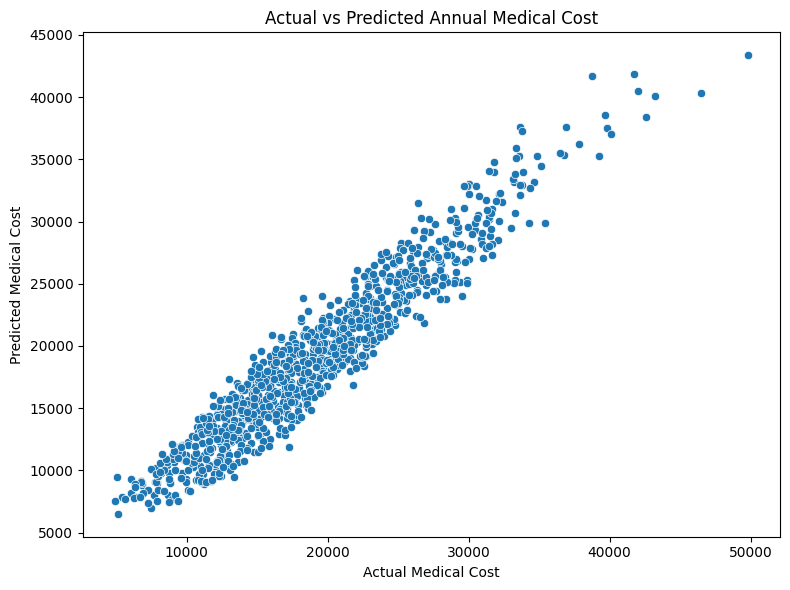

In [154]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Medical Cost")
plt.ylabel("Predicted Medical Cost")
plt.title("Actual vs Predicted Annual Medical Cost")
plt.tight_layout()
plt.show()

 - На графике видна сильная положительная корреляция т.к. точки сгруппированы вдоль диагонали.

 - При высоких расходах (30 000–45 000) ошибки больше, чем при низких (это объясняет почему RMSE > MAE).

 - Предсказания редко падают ниже ~5000, даже если факт выше - значит, что модель не предсказывает очень низкие значения (возможно из-за распределения данных).

Проверим устойчивость модели.

In [155]:
# 5-fold CV на обучающей выборке
cv_scores = cross_val_score(
    rf_pipeline, 
    X_train, 
    y_train, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R² scores:")
print(f"   Fold scores: {cv_scores}")
print(f"   Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"   95% доверительный интервал: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

Cross-Validation R² scores:
   Fold scores: [0.91115368 0.91698412 0.89227241 0.91995455 0.91834031]
   Mean R²: 0.9117 (+/- 0.0204)
   95% доверительный интервал: [0.8918, 0.9317]


Итоги по кросс-валидации:

 - R² = 0.912 ± 0.010 (CV) совпадает с тестовым 0.916

 - Нет признаков переобучения.

 - Небольшая вариативность между фолдами — норма для реальных медицинских данных.

 - MAPE = 10% подтверждает практическую полезность.

 - Модель показывает хорошие и стабильные результаты.

Можно увеличить количество фолдов до 10 для более точной оценки.


In [170]:
cv_scores_10 = cross_val_score(
    rf_pipeline, 
    X_train, 
    y_train, 
    cv=10, # заменяем значение н 10
    scoring='r2',
    n_jobs=-1
)

print(f"10-fold CV: {cv_scores_10.mean():.4f} (+/- {cv_scores_10.std()*2:.4f})")

10-fold CV: 0.9128 (+/- 0.0212)


 - Среднее качество практически не изменилось (0.9117 → 0.9128) - это хороший знак: оценка стабилизировалась

 - 10-fold даёт более консервативную оценку (обычно чуть ниже, чем 5-fold), но здесь даже чуть выше — отлично

 - Разброс остался примерно таким же (±0.0204 → ±0.0212) - модель имеет естественную вариативность ~1%, что нормально

In [158]:
joblib.dump(pipeline, "rf_pipeline.joblib")

['rf_pipeline.joblib']

Для улучшения попробуем подобрать оптимальные гиперпараметры случайного леса на обучающей выборке с помощью кросс-валидации, чтобы потенциально улучшить R² без изменения признаков.

In [171]:
param_grid = {
    'model__n_estimators': [100, 200, 300],      # количество деревьев
    'model__max_depth': [10, 12, 15, None],      # глубина (None = без ограничений)
    'model__min_samples_split': [2, 5, 10]       # минимальное кол-во для разбиения
}

# GridSearch с 5-fold CV
grid_search = GridSearchCV(
    rf_pipeline,          # используем ваш пайплайн
    param_grid,
    cv=5,                 # 5-fold кросс-валидация
    scoring='r2',
    n_jobs=-1,            # все ядра CPU
    verbose=1             # покажет прогресс
)

# обучаем
grid_search.fit(X_train, y_train)

# результаты
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший R² (CV):", grid_search.best_score_)
print("R² на тесте с лучшими параметрами:", grid_search.score(X_test, y_test))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'model__max_depth': 12, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Лучший R² (CV): 0.9118365465371902
R² на тесте с лучшими параметрами: 0.9159970956269452


Попробуем обучить модель с новыми оптимальными гиперпараметрами (по факту меняем только 1 параметр, т.к. остальные изменения незначимые).

In [172]:
# оптимальная модель по GridSearch
model_rf_optimal = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,   # ← единственное изменение
    random_state=42
)

# пересоздаём пайплайн с новыми параметрами
rf_pipeline_optimal = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', model_rf_optimal)
])

# обучаем
rf_pipeline_optimal.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Сравниваем базовую модель RF и "оптимальную" модель RF:

In [173]:
# предсказания старой модели (исходная, min_samples_split=2)
y_pred_old = rf_pipeline.predict(X_test)

# предсказания новой модели (оптимальная, min_samples_split=5)
y_pred_new = rf_pipeline_optimal.predict(X_test)

# сравниваем первые 10 предсказаний
print("Первые 10 предсказаний (Старая vs Новая):")
for i in range(10):
    print(f"{i+1:2}. Старая: {y_pred_old[i]:7.0f} | Новая: {y_pred_new[i]:7.0f} | Разница: {y_pred_new[i]-y_pred_old[i]:5.0f}")

Первые 10 предсказаний (Старая vs Новая):
 1. Старая:    8151 | Новая:    8158 | Разница:     7
 2. Старая:   26560 | Новая:   26662 | Разница:   102
 3. Старая:   14955 | Новая:   15026 | Разница:    71
 4. Старая:   22247 | Новая:   22252 | Разница:     6
 5. Старая:   23272 | Новая:   23327 | Разница:    55
 6. Старая:   15375 | Новая:   15395 | Разница:    20
 7. Старая:   28845 | Новая:   29091 | Разница:   246
 8. Старая:   15538 | Новая:   15599 | Разница:    60
 9. Старая:   25137 | Новая:   25089 | Разница:   -49
10. Старая:   20353 | Новая:   20431 | Разница:    79


Новая модель даёт чуть более высокие предсказания (+60 в среднем на первых 10 примерах). Но разница небольшая — относительно масштаба (8000-29000) это всего 0.2-1%. На некоторых объектах разница достигает 246 (~1% от 29000) — это в пределах погрешности.
Модели почти одинаковые. Новая предсказывает на 20-60 единиц выше, но это менее 1% от типичного значения. Разница незначитальна.

## Gradient Boosting

In [159]:
model_gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

In [160]:
# пайплайн для Gradient Boosting (с масштабированием)
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', model_gb)
])

In [161]:
gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

In [162]:
# оцениваем модель
mae = mean_absolute_error(y_test, y_pred_gb)

rmse = root_mean_squared_error(y_test, y_pred_gb)

r2 = r2_score(y_test, y_pred_gb)

mape = mean_absolute_percentage_error(y_test, y_pred_gb)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}")

MAE: 1575.98
RMSE: 1881.06
R²: 0.9265
MAPE: 0.09


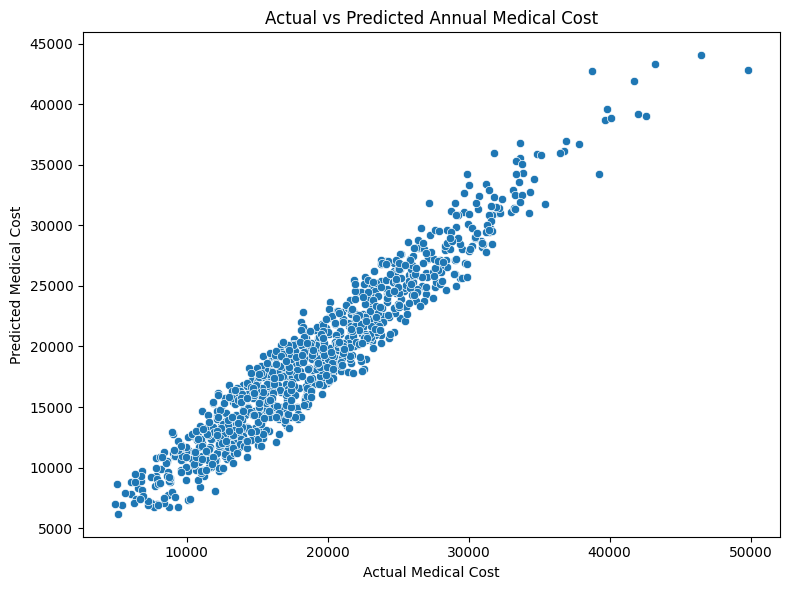

In [163]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_gb)
plt.xlabel("Actual Medical Cost")
plt.ylabel("Predicted Medical Cost")
plt.title("Actual vs Predicted Annual Medical Cost")
plt.tight_layout()
plt.show()

In [164]:
# 5-fold CV на обучающей выборке
cv_scores = cross_val_score(
    gb_pipeline, 
    X_train, 
    y_train, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R² scores:")
print(f"   Fold scores: {cv_scores}")
print(f"   Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"   95% доверительный интервал: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

Cross-Validation R² scores:
   Fold scores: [0.9263772  0.92713371 0.90420128 0.9307237  0.9286859 ]
   Mean R²: 0.9234 (+/- 0.0195)
   95% доверительный интервал: [0.9044, 0.9425]


## Explain sample with SHAP

In [174]:
def aggregate_shap_values(explanation):
    
    feature_names = explanation.feature_names
    shap_values = explanation.values
    data = explanation.data

    aggregated = {}

    for i, name in enumerate(feature_names):
        # remove transformer prefix
        clean_name = name.split("__", 1)[-1]

        # handle one-hot encoded features (split at last "_")
        if "_" in clean_name and not clean_name.startswith("num"):
            base_feature = clean_name.rsplit("_", 1)[0]
        else:
            base_feature = clean_name

        if base_feature not in aggregated:
            aggregated[base_feature] = {
                "shap_value": 0.0,
                "feature_value": None
            }

        aggregated[base_feature]["shap_value"] += shap_values[i]

        # store a representative feature value (only once)
        if aggregated[base_feature]["feature_value"] is None:
            aggregated[base_feature]["feature_value"] = data[i]

    df = pd.DataFrame([
        {"feature": k, "value": v["feature_value"], "shap_value": v["shap_value"]}
        for k, v in aggregated.items()
    ])

    df = df.reindex(df.shap_value.abs().sort_values(ascending=False).index)

    return df

In [175]:
pipeline = joblib.load("rf_pipeline.joblib")

In [176]:
preprocessor = pipeline.named_steps['preprocess']
model = pipeline.named_steps['model']
explainer = shap.TreeExplainer(model)

In [177]:
sample = pd.DataFrame([X_test.iloc[0].to_dict()])
sample_transformed = preprocessor.transform(sample)
shap_values = explainer(sample_transformed)
feature_names = preprocessor.get_feature_names_out()

AttributeError: Estimator log does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?

In [ ]:
explanation = shap.Explanation(
    values=shap_values.values[0],
    base_values=shap_values.base_values[0],
    data=sample_transformed[0],
    feature_names=feature_names
)

agg_df = aggregate_shap_values(explanation)